In [ ]:
import numpy as np
import time
import pickle
import pandas as pd
import re
import matplotlib.pyplot as plt
import torch
import os
import pickle
import pandas as pd
from pathlib import Path
import re
from torchvision import transforms
from medmnist import PathMNIST
import matplotlib.pyplot as plt
from matplotlib.colors import rgb_to_hsv, hsv_to_rgb
from eqCLR.eq_resnet import EqResNet18, EqResNet18_hue, EqResNet_hue
from evaluation import model_eval, eval_knn_single, dataset_to_X_y, lin_eval_rep
import torch.nn as nn
from torchvision.models import resnet18

In [2]:
class RandomRightAngleRotation:
    """Randomly rotate PIL image by 90, 180, or 270 degrees."""
    def __call__(self, x):
        angle = int(torch.randint(1, 4, ()).item()) * 90
        return x.rotate(angle)

In [3]:
class RGBToHSV:
    def __init__(self, hue_shift=0.0):
        """
        hue_shift: shift hue by this amount (in [0,1]).
        """
        self.hue_shift = hue_shift
    """Custom transform: convert RGB tensor [C,H,W] in [0,1] to HSV [C,H,W]"""
    
    def __call__(self, img_tensor):
        # img_tensor: [C,H,W] in [0,1]
        img_np = img_tensor.permute(1, 2, 0).numpy()  # [H,W,C]
        hsv_np = rgb_to_hsv(img_np)                    # [H,W,C], hue in [0,1]
        
        if self.hue_shift:
            hsv_np[..., 0] = (hsv_np[..., 0] + self.hue_shift) % 1.0

        hsv_tensor = torch.tensor(hsv_np).permute(2, 0, 1)  # back to [C,H,W]
        return hsv_tensor

# PathMNIST

In [4]:
path_perf = {}

knns = []
times = []

# Resnet
for rs in range(3):
    eval_path = f'results_hue/pathmnist/model_eval/1001-seed_{rs}_pathmnist_hsv-resnet18_eval.pkl'
    details_path = f'results_hue/pathmnist/model_details/1001-seed_{rs}_pathmnist_hsv-resnet18_details.pkl'

    with open(eval_path, 'rb') as f:
        eval = pickle.load(f)

    with open(details_path, 'rb') as f:
        details = pickle.load(f)

    knns.append(eval['euclidean'][10])
    times.append(details['Training time w/o evaluation'] / details['N_EPOCHS'])

path_perf['SimCLR'] = {}
path_perf['SimCLR']['KNN'] = np.mean(knns)
path_perf['SimCLR']['KNN_std'] = np.std(knns)
path_perf['SimCLR']['time'] = np.mean(times)
path_perf['SimCLR']['time_std'] = np.std(times)

# equivariant SimCLR
for n in [4, 8]:
    knns = []
    times = []
    for rs in range(3):
        if n ==8 and rs==2:
            continue  
        eval_path = f'results_hue/pathmnist/model_eval/0001-seed{rs}_pathmnist_hue_eqCLR_N{n}_eval.pkl'
        details_path = f'results_hue/pathmnist/model_details/0001-seed{rs}_pathmnist_hue_eqCLR_N{n}_details.pkl'

        with open(eval_path, 'rb') as f:
            eval = pickle.load(f)

        with open(details_path, 'rb') as f:
            details = pickle.load(f)

        knns.append(eval['euclidean'][10])
        times.append(details['Training time w/o evaluation'] / details['N_EPOCHS'])

    path_perf[f'eqCLR_N={n}'] = {}
    path_perf[f'eqCLR_N={n}']['KNN'] = np.mean(knns)
    path_perf[f'eqCLR_N={n}']['KNN_std'] = np.std(knns)
    path_perf[f'eqCLR_N={n}']['time'] = np.mean(times)
    path_perf[f'eqCLR_N={n}']['time_std'] = np.std(times)

# mixed equivariant SimCLR
for n in [4, 8]:
    knns = []
    times = []
    for rs in range(2):
        eval_path = f'results_hue/pathmnist/model_eval/0002-seed{rs}_pathmnist_hue_eqCLR_mixed_N{n}_eval.pkl'
        details_path = f'results_hue/pathmnist/model_details/0002-seed{rs}_pathmnist_hue_eqCLR_mixed_N{n}_details.pkl'

        with open(eval_path, 'rb') as f:
            eval = pickle.load(f)

        with open(details_path, 'rb') as f:
            details = pickle.load(f)

        knns.append(eval['euclidean'][10])
        times.append(details['Training time w/o evaluation'] / details['N_EPOCHS'])

    path_perf[f'mixed_eqCLR_N={n}'] = {}
    path_perf[f'mixed_eqCLR_N={n}']['KNN'] = np.mean(knns)
    path_perf[f'mixed_eqCLR_N={n}']['KNN_std'] = np.std(knns)
    path_perf[f'mixed_eqCLR_N={n}']['time'] = np.mean(times)
    path_perf[f'mixed_eqCLR_N={n}']['time_std'] = np.std(times)

path_perf_df = pd.DataFrame(path_perf).T
display(path_perf_df)


,KNN,KNN_std,time,time_std
SimCLR,0.851021,0.006932,11.881532,0.045912
eqCLR_N=4,0.828134,0.001675,18.945422,0.148534
eqCLR_N=8,0.822006,0.000557,30.707832,0.021151
mixed_eqCLR_N=4,0.822145,0.001253,13.670783,0.056221
mixed_eqCLR_N=8,0.813231,0.003343,17.826142,0.086897


In [11]:
# Default SimCLR and eqCLR
path_perf_rgb = {}

knns = []
times = []

# Resnet
for rs in range(3):
    eval_path = f'results_mlc/pathmnist/model_eval/C-1003_seed{rs}_pathmnist_28_no_resize-resnet18_100epochs_eval.pkl'

    with open(eval_path, 'rb') as f:
        eval = pickle.load(f)

    knns.append(eval['euclidean'][10])

path_perf_rgb['ResNet18'] = {}
path_perf_rgb['ResNet18']['KNN'] = np.mean(knns)
path_perf_rgb['ResNet18']['KNN_std'] = np.std(knns)

# equivariant SimCLR
for n in [4, 8]:
    knns = []
    times = []
    for rs in range(3):
        eval_path = f'results_mlc/pathmnist/model_eval/C-0001_seed{rs}_pathmnist_33-eqCLR_resnet18_N{n}_rot_kp_100epochs_b512_eval.pkl'

        with open(eval_path, 'rb') as f:
            eval = pickle.load(f)

        knns.append(eval['euclidean'][10])

    path_perf_rgb[f'eqResNet_N={n}'] = {}
    path_perf_rgb[f'eqResNet_N={n}']['KNN'] = np.mean(knns)
    path_perf_rgb[f'eqResNet_N={n}']['KNN_std'] = np.std(knns)

# mixed equivariant SimCLR
for n in [4, 8]:
    knns = []
    times = []
    for rs in range(3):
        eval_path = f'results_mlc/pathmnist/model_eval/C-0002_seed{rs}_pathmnist_33-mixed_eqCLR_resnet18_2eqblocks_N{n}_rot_kp_100epochs_eval.pkl'

        with open(eval_path, 'rb') as f:
            eval = pickle.load(f)

        knns.append(eval['euclidean'][10])

    path_perf_rgb[f'mixed_eqResNet_N={n}'] = {}
    path_perf_rgb[f'mixed_eqResNet_N={n}']['KNN'] = np.mean(knns)
    path_perf_rgb[f'mixed_eqResNet_N={n}']['KNN_std'] = np.std(knns)

path_perf_rgb_df = pd.DataFrame(path_perf_rgb).T
display(path_perf_rgb_df)

,KNN,KNN_std
ResNet18,0.859099,0.001741
eqResNet_N=4,0.896750,0.002624
eqResNet_N=8,0.902321,0.001057
mixed_eqResNet_N=4,0.894104,0.001440
mixed_eqResNet_N=8,0.895543,0.002240


Text(3.5, 0.7952141141751312, 'mixed eqCLR')

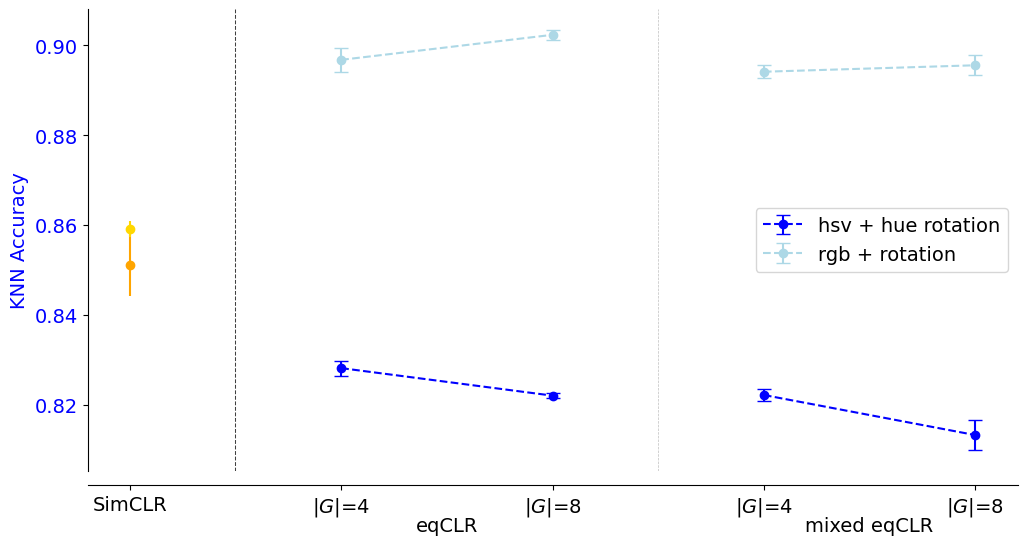

In [50]:
fig, ax = plt.subplots(figsize=(12, 6))
fontsize = 14

labels_eq = ['N=4', 'N=8']
labels_mixed = ['N=4', 'N=8']

x_resnet = 0
x_eq1 = np.array([1, 2])
x_mixed1 = np.array([3, 4])

# ResNet18
ax.errorbar(
    x_resnet,
    path_perf['SimCLR']['KNN'],
    yerr=path_perf['SimCLR']['KNN_std'],
    fmt='o',
    color='orange'
)
# ResNet18 (RGB)
ax.errorbar(
    x_resnet,
    path_perf_rgb['ResNet18']['KNN'],
    yerr=path_perf_rgb['ResNet18']['KNN_std'],
    fmt='o',
    color='gold'
)

ax.axvline(0.5, linestyle='--', linewidth=0.75, alpha=0.75, color='black', zorder=1)

# eqResNet hue
ax.errorbar(
    x_eq1,
    [path_perf[f'eqCLR_{label}']['KNN'] for label in labels_eq],
    yerr=[path_perf[f'eqCLR_{label}']['KNN_std'] for label in labels_eq],
    fmt='--o',
    capsize=5,
    color='blue'
)
# eqResNet rot
ax.errorbar(
    x_eq1,
    [path_perf_rgb[f'eqResNet_{label}']['KNN'] for label in labels_eq],
    yerr=[path_perf_rgb[f'eqResNet_{label}']['KNN_std'] for label in labels_eq],
    fmt='--o',
    capsize=5,
    color='lightblue'
)
ax.axvline(2.5, linestyle='--', linewidth=0.5, alpha=0.5, color='gray', zorder=1)

# mixed hue
ax.errorbar(
    x_mixed1,
    [path_perf[f'mixed_eqCLR_{label}']['KNN'] for label in labels_mixed],
    yerr=[path_perf[f'mixed_eqCLR_{label}']['KNN_std'] for label in labels_mixed],
    fmt='--o',
    capsize=5,
    color='blue',
    label='hsv + hue rotation'
)
# mixed rot
ax.errorbar(
    x_mixed1,
    [path_perf_rgb[f'mixed_eqResNet_{label}']['KNN'] for label in labels_mixed],
    yerr=[path_perf_rgb[f'mixed_eqResNet_{label}']['KNN_std'] for label in labels_mixed],
    fmt='--o',
    capsize=5,
    color='lightblue',
    label='rgb + rotation'
)

ax.set_xticks(
    [x_resnet] + list(x_eq1) + list(x_mixed1)
)

ax.set_xticklabels(
    ['SimCLR'] + [r'$|G|$=4', r'$|G|$=8'] + [r'$|G|$=4', r'$|G|$=8']
)

ax.set_ylabel('KNN Accuracy', color='blue', fontsize=fontsize)
ax.tick_params(axis='y', labelcolor='blue', labelsize=fontsize)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='x', labelsize=fontsize)
ax.spines['bottom'].set_position(('outward', 10))
ax.legend(frameon=True, fontsize=fontsize)

ax.text(1.5, ax.get_ylim()[0] - 0.01, "eqCLR", ha='center', va='top', fontsize=fontsize)
ax.text(3.5, ax.get_ylim()[0] - 0.01, "mixed eqCLR", ha='center', va='top', fontsize=fontsize)

## Prediction consistency

In [24]:
PROJECTOR_HIDDEN_SIZE = 1024
PROJECTOR_OUTPUT_SIZE = 128

In [25]:
eqCLR = EqResNet18_hue(N=4, projector_hidden_size=PROJECTOR_HIDDEN_SIZE, n_classes=PROJECTOR_OUTPUT_SIZE, adjust_channels='keep_param')


S = 2.0
Make layer
Make layer
Make layer
Make layer
Final feature dimension: 256


In [26]:
mixed_eqCLR = EqResNet_hue(N=4, eq_blocks=2, projector_hidden_size=PROJECTOR_HIDDEN_SIZE, n_classes=PROJECTOR_OUTPUT_SIZE, adjust_channels='keep_param')

Make equivariant layer
Make equivariant layer
Make non-equivariant layer
Make non-equivariant layer
Hidden dim before projection head: 512


In [27]:
class ResNetwithProjector(nn.Module):
    def __init__(self, backbone_network, maxpool=True):
        super().__init__()
        self.backbone = backbone_network(weights=None)
        self.backbone_output_dim = self.backbone.fc.in_features
        if not maxpool:
            self.backbone.conv1 = nn.Conv2d(
                3, 64, kernel_size=3, stride=1, padding=1, bias=False
            )
            self.backbone.maxpool = nn.Identity()
            
        self.backbone.fc = nn.Identity()
        self.projector = nn.Sequential(
            nn.Linear(self.backbone_output_dim, PROJECTOR_HIDDEN_SIZE), 
            nn.ReLU(), 
            nn.Linear(PROJECTOR_HIDDEN_SIZE, PROJECTOR_OUTPUT_SIZE),
        )
    def forward(self, x):
        h = self.backbone(x)
        z = self.projector(h)
        return h, z
    
simclr = ResNetwithProjector(resnet18, maxpool=True)

In [28]:
eqCLR_weights = {
    rs: f'results_hue/pathmnist/model_weights/0001-seed{rs}_pathmnist_hue_eqCLR_N4_weights.pt' for rs in range(3)
}
mixed_eqCLR_weights = {
    rs: f'results_hue/pathmnist/model_weights/0002-seed{rs}_pathmnist_hue_eqCLR_mixed_N4_weights.pt' for rs in range(2)
}
simclr_weights = {
    rs: f'results_hue/pathmnist/model_weights/1001-seed_{rs}_pathmnist_hsv-resnet18_weights.pt' for rs in range(3)
}

In [4]:
# Load data
transform = transforms.Compose([
            transforms.Resize((33, 33)),
            transforms.ToTensor(),
            RGBToHSV()
        ])
pmnist_train = PathMNIST(split='train', download=False, size=28, root='data/pathmnist/', transform=transform)
pmnist_test = PathMNIST(split='test', download=False, size=28, root='data/pathmnist/', transform=transform)

hue_path = {}

for shift in np.linspace(0, 1, 17):
    transform = transforms.Compose([
            transforms.Resize((33, 33)),
            transforms.ToTensor(),
            RGBToHSV(hue_shift=shift)
        ])

    data = PathMNIST(split='test', download=False, size=28, root='data/pathmnist/', transform=transform)
    hue_path[shift] = data


In [33]:
# Load data (no resize)
transform = transforms.Compose([
            # transforms.Resize((33, 33)),
            transforms.ToTensor(),
            RGBToHSV()
        ])
pmnist_train_nr = PathMNIST(split='train', download=False, size=28, root='data/pathmnist/', transform=transform)
pmnist_test_nr = PathMNIST(split='test', download=False, size=28, root='data/pathmnist/', transform=transform)

hue_path_nr = {}

for shift in np.linspace(0, 1, 17):
    transform = transforms.Compose([
            transforms.ToTensor(),
            RGBToHSV(hue_shift=shift)
        ])

    data = PathMNIST(split='test', download=False, size=28, root='data/pathmnist/', transform=transform)
    hue_path_nr[shift] = data


In [40]:
device = "cuda"
simclr.to(device)
eqCLR.to(device)
mixed_eqCLR.to(device)
simclr.eval()
eqCLR.eval()
mixed_eqCLR.eval()

EqResNet_hue(
  (encoder): HSVHuePhaseEncoder()
  (eq_stages): ModuleList(
    (0): R2Conv([C4_on_R2[hueOnR2(H=4)]: {irrep_1 (x1), irrep_0 (x2)}(4)], [C4_on_R2[hueOnR2(H=4)]: {regular (x32)}(128)], kernel_size=7, stride=2, padding=3)
    (1): InnerBatchNorm([C4_on_R2[hueOnR2(H=4)]: {regular (x32)}(128)], eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=False, type=[C4_on_R2[hueOnR2(H=4)]: {regular (x32)}(128)])
    (3): PointwiseMaxPool2D()
    (4): SequentialModule(
      (0): EqBasicBlock(
        (conv1): R2Conv([C4_on_R2[hueOnR2(H=4)]: {regular (x32)}(128)], [C4_on_R2[hueOnR2(H=4)]: {regular (x32)}(128)], kernel_size=3, stride=1, padding=1, bias=False)
        (bn1): InnerBatchNorm([C4_on_R2[hueOnR2(H=4)]: {regular (x32)}(128)], eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=False, type=[C4_on_R2[hueOnR2(H=4)]: {regular (x32)}(128)])
        (conv2): R2Conv([C4_on_R2[hueOnR2(H=4)]: {regular (x32)}(12

In [41]:
eval_hue_shifts = {}
eval_hue_shifts['SimCLR'] = {}
eval_hue_shifts['eqCLR'] = {}
eval_hue_shifts['mixed_eqCLR'] = {}

with torch.no_grad():
    for rs in range(3):
        print(f"Evaluating seed {rs}...")
        eval_hue_shifts['SimCLR'][f'seed{rs}'] = {}
        eval_hue_shifts['eqCLR'][f'seed{rs}'] = {}
        if rs < 2: 
            eval_hue_shifts['mixed_eqCLR'][f'seed{rs}'] = {}

        # Load weights
        simclr.load_state_dict(torch.load(simclr_weights[rs], weights_only=True))
        eqCLR.load_state_dict(torch.load(eqCLR_weights[rs], weights_only=True))
        if rs < 2:  # We only have 2 seeds for mixed_eqCLR
            mixed_eqCLR.load_state_dict(torch.load(mixed_eqCLR_weights[rs], weights_only=True))

        # SimCLR
        X_train_sim, y_train_sim, Z_train_sim = dataset_to_X_y(pmnist_train_nr, simclr)
        # eqCLR
        X_train_eq, y_train_eq, Z_train_eq = dataset_to_X_y(pmnist_train, eqCLR)
        # mixed_eqCLR
        if rs < 2:  
            X_train_mixed, y_train_mixed, Z_train_mixed = dataset_to_X_y(pmnist_train, mixed_eqCLR)

        for shift in hue_path.keys():
            print(f"Evaluating hue shift {shift}...")

            # Test data
            X_test_sim, y_test_sim, Z_test_sim = dataset_to_X_y(hue_path_nr[shift], simclr)
            X_test_eq, y_test_eq, Z_test_eq = dataset_to_X_y(hue_path[shift], eqCLR)
            if rs < 2:  
                X_test_mixed, y_test_mixed, Z_test_mixed = dataset_to_X_y(hue_path[shift], mixed_eqCLR)

            # KNN
            knn_sim = eval_knn_single(X_train_sim, y_train_sim, X_test_sim, y_test_sim)
            knn_eq = eval_knn_single(X_train_eq, y_train_eq, X_test_eq, y_test_eq)
            knn_mixed = eval_knn_single(X_train_mixed, y_train_mixed, X_test_mixed, y_test_mixed)

            eval_hue_shifts['SimCLR'][f'seed{rs}'][shift] = knn_sim
            eval_hue_shifts['eqCLR'][f'seed{rs}'][shift] = knn_eq
            if rs < 2:  
                eval_hue_shifts['mixed_eqCLR'][f'seed{rs}'][shift] = knn_mixed


Evaluating seed 0...
Evaluating hue shift 0.0...
Evaluating hue shift 0.0625...
Evaluating hue shift 0.125...
Evaluating hue shift 0.1875...
Evaluating hue shift 0.25...
Evaluating hue shift 0.3125...
Evaluating hue shift 0.375...
Evaluating hue shift 0.4375...
Evaluating hue shift 0.5...
Evaluating hue shift 0.5625...
Evaluating hue shift 0.625...
Evaluating hue shift 0.6875...
Evaluating hue shift 0.75...
Evaluating hue shift 0.8125...
Evaluating hue shift 0.875...
Evaluating hue shift 0.9375...
Evaluating hue shift 1.0...
Evaluating seed 1...
Evaluating hue shift 0.0...
Evaluating hue shift 0.0625...
Evaluating hue shift 0.125...
Evaluating hue shift 0.1875...
Evaluating hue shift 0.25...
Evaluating hue shift 0.3125...
Evaluating hue shift 0.375...
Evaluating hue shift 0.4375...
Evaluating hue shift 0.5...
Evaluating hue shift 0.5625...
Evaluating hue shift 0.625...
Evaluating hue shift 0.6875...
Evaluating hue shift 0.75...
Evaluating hue shift 0.8125...
Evaluating hue shift 0.875.

In [42]:
simclr_df = pd.DataFrame(eval_hue_shifts['SimCLR']).T
display(simclr_df)

simclr_mean = simclr_df.mean()
simclr_std = simclr_df.std()
print("SimCLR KNN mean:", simclr_mean)
print("SimCLR KNN std:", simclr_std)

,0.0000,0.0625,0.1250,0.1875,0.2500,0.3125,0.3750,0.4375,0.5000,0.5625,0.6250,0.6875,0.7500,0.8125,0.8750,0.9375,1.0000
seed0,0.855571,0.851532,0.700696,0.359610,0.508635,0.566295,0.610864,0.626741,0.644290,0.666713,0.706267,0.772145,0.810306,0.835655,0.848747,0.849164,0.855571
seed1,0.856267,0.852368,0.709471,0.431476,0.522563,0.554178,0.575209,0.592897,0.608078,0.614485,0.624513,0.645404,0.713788,0.813231,0.844708,0.849443,0.856407
seed2,0.841226,0.841226,0.700836,0.459889,0.594708,0.613649,0.619638,0.627855,0.629109,0.628412,0.633008,0.663649,0.731476,0.812674,0.833844,0.836630,0.841226


SimCLR KNN mean: 0.0000    0.851021
0.0625    0.848375
0.1250    0.703668
0.1875    0.416992
0.2500    0.541968
0.3125    0.578041
0.3750    0.601903
0.4375    0.615831
0.5000    0.627159
0.5625    0.636537
0.6250    0.654596
0.6875    0.693733
0.7500    0.751857
0.8125    0.820520
0.8750    0.842433
0.9375    0.845079
1.0000    0.851068
dtype: float64
SimCLR KNN std: 0.0000    0.008490
0.0625    0.006206
0.1250    0.005026
0.1875    0.051685
0.2500    0.046201
0.3125    0.031427
0.3750    0.023531
0.4375    0.019869
0.5000    0.018184
0.5625    0.027045
0.6250    0.044950
0.6875    0.068517
0.7500    0.051385
0.8125    0.013110
0.8750    0.007707
0.9375    0.007319
1.0000    0.008534
dtype: float64


In [43]:
eq_df = pd.DataFrame(eval_hue_shifts['eqCLR']).T
display(eq_df)

eq_mean = eq_df.mean()
eq_std = eq_df.std()
print("eqCLR KNN mean:", eq_mean)
print("eqCLR KNN std:", eq_std)

,0.0000,0.0625,0.1250,0.1875,0.2500,0.3125,0.3750,0.4375,0.5000,0.5625,0.6250,0.6875,0.7500,0.8125,0.8750,0.9375,1.0000
seed0,0.826880,0.825766,0.827019,0.825070,0.826880,0.826045,0.827019,0.825209,0.826880,0.825905,0.827019,0.825209,0.826880,0.825905,0.827019,0.825070,0.826880
seed1,0.827019,0.828134,0.824373,0.822563,0.827019,0.827994,0.824234,0.822563,0.827019,0.828134,0.824234,0.822563,0.827019,0.828134,0.824234,0.822563,0.827019
seed2,0.830501,0.827855,0.831058,0.835376,0.830501,0.827855,0.831198,0.835376,0.830501,0.827855,0.831198,0.835376,0.830501,0.827855,0.831198,0.835376,0.830501


eqCLR KNN mean: 0.0000    0.828134
0.0625    0.827252
0.1250    0.827484
0.1875    0.827669
0.2500    0.828134
0.3125    0.827298
0.3750    0.827484
0.4375    0.827716
0.5000    0.828134
0.5625    0.827298
0.6250    0.827484
0.6875    0.827716
0.7500    0.828134
0.8125    0.827298
0.8750    0.827484
0.9375    0.827669
1.0000    0.828134
dtype: float64
eqCLR KNN std: 0.0000    0.002052
0.0625    0.001294
0.1250    0.003367
0.1875    0.006791
0.2500    0.002052
0.3125    0.001088
0.3750    0.003505
0.4375    0.006765
0.5000    0.002052
0.5625    0.001214
0.6250    0.003505
0.6875    0.006765
0.7500    0.002052
0.8125    0.001214
0.8750    0.003505
0.9375    0.006791
1.0000    0.002052
dtype: float64


In [44]:
mixed_df = pd.DataFrame(eval_hue_shifts['mixed_eqCLR']).T
display(mixed_df)

mixed_mean = mixed_df.mean()
mixed_std = mixed_df.std()
print("mixed_eqCLR KNN mean:", mixed_mean)
print("mixed_eqCLR KNN std:", mixed_std)

,0.0000,0.0625,0.1250,0.1875,0.2500,0.3125,0.3750,0.4375,0.5000,0.5625,0.6250,0.6875,0.7500,0.8125,0.8750,0.9375,1.0000
seed0,0.820891,0.821309,0.823120,0.826184,0.820752,0.821309,0.823120,0.826184,0.820891,0.821309,0.823120,0.826184,0.820752,0.821309,0.823120,0.826184,0.820891
seed1,0.823398,0.825627,0.825209,0.823955,0.823398,0.825627,0.825209,0.823955,0.823398,0.825627,0.825209,0.823955,0.823398,0.825627,0.825209,0.823955,0.823259


mixed_eqCLR KNN mean: 0.0000    0.822145
0.0625    0.823468
0.1250    0.824164
0.1875    0.825070
0.2500    0.822075
0.3125    0.823468
0.3750    0.824164
0.4375    0.825070
0.5000    0.822145
0.5625    0.823468
0.6250    0.824164
0.6875    0.825070
0.7500    0.822075
0.8125    0.823468
0.8750    0.824164
0.9375    0.825070
1.0000    0.822075
dtype: float64
mixed_eqCLR KNN std: 0.0000    0.001773
0.0625    0.003053
0.1250    0.001477
0.1875    0.001576
0.2500    0.001871
0.3125    0.003053
0.3750    0.001477
0.4375    0.001576
0.5000    0.001773
0.5625    0.003053
0.6250    0.001477
0.6875    0.001576
0.7500    0.001871
0.8125    0.003053
0.8750    0.001477
0.9375    0.001576
1.0000    0.001674
dtype: float64


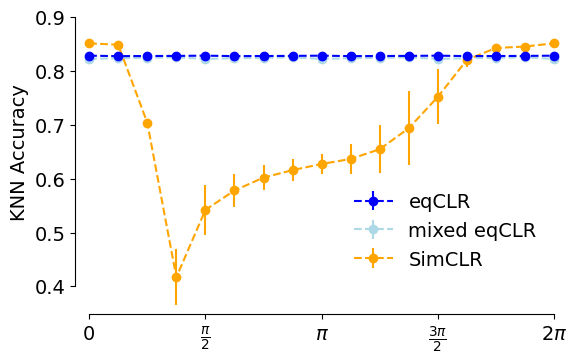

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(5, 4))
font_size = 14
ax.tick_params(axis='both', which='major', labelsize=font_size)

ax.errorbar(eq_mean.index, eq_mean.values, yerr=eq_std.values, label='eqCLR', fmt='--o', clip_on=False, color='blue', zorder=5)
ax.errorbar(mixed_mean.index, mixed_mean.values, yerr=mixed_std.values, label='mixed eqCLR', fmt='--o', clip_on=False, color='lightblue', zorder=-1)
ax.errorbar(simclr_mean.index, simclr_mean.values, yerr=simclr_std.values, label='SimCLR', fmt='--o', clip_on=False, color='orange')


# ax.set_xlabel('test set hue rotation', fontsize=font_size)
ax.set_ylabel('KNN Accuracy', fontsize=font_size)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.spines['bottom'].set_position(('outward', 20))
ax.spines['left'].set_position(('outward', 10))

ax.set_xlim(0, 1)
ax.set_xticks([0, 0.25, 0.5, 0.75, 1])
ax.set_xticklabels([
    '0',
    r'$\frac{\pi}{2}$',
    r'$\pi$',
    r'$\frac{3\pi}{2}$',
    r'$2\pi$'
])
ax.set_ylim(0.4, 0.9)
ax.set_yticks([0.4, 0.5, 0.6, 0.7, 0.8, 0.9])

ax.legend(fontsize=font_size, frameon=False)

plt.savefig('figures/hue_equivariance2.svg', bbox_inches='tight')

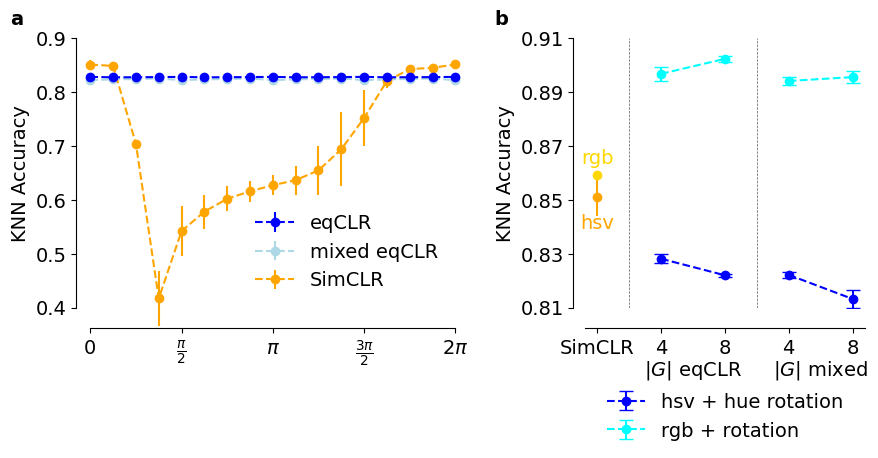

In [110]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3.5), gridspec_kw={'width_ratios': [1.3, 1], 'wspace': 0.4})

fontsize = 14

ax[0].tick_params(axis='both', which='major', labelsize=fontsize)

ax[0].errorbar(eq_mean.index, eq_mean.values, yerr=eq_std.values, label='eqCLR', fmt='--o', clip_on=False, color='blue', zorder=5)
ax[0].errorbar(mixed_mean.index, mixed_mean.values, yerr=mixed_std.values, label='mixed eqCLR', fmt='--o', clip_on=False, color='lightblue', zorder=-1)
ax[0].errorbar(simclr_mean.index, simclr_mean.values, yerr=simclr_std.values, label='SimCLR', fmt='--o', clip_on=False, color='orange')


# ax.set_xlabel('test set hue rotation', fontsize=font_size)
ax[0].set_ylabel('KNN Accuracy', fontsize=fontsize)

ax[0].spines['top'].set_visible(False)
ax[0].spines['right'].set_visible(False)

ax[0].spines['bottom'].set_position(('outward', 15))
ax[0].spines['left'].set_position(('outward', 10))

ax[0].set_xlim(0, 1)
ax[0].set_xticks([0, 0.25, 0.5, 0.75, 1])
ax[0].set_xticklabels([
    '0',
    r'$\frac{\pi}{2}$',
    r'$\pi$',
    r'$\frac{3\pi}{2}$',
    r'$2\pi$'
])
ax[0].set_ylim(0.4, 0.9)
ax[0].set_yticks([0.4, 0.5, 0.6, 0.7, 0.8, 0.9])

ax[0].legend(fontsize=fontsize, frameon=False)

# plot b)
labels_eq = ['N=4', 'N=8']
labels_mixed = ['N=4', 'N=8']

x_resnet = 0
x_eq1 = np.array([1, 2])
x_mixed1 = np.array([3, 4])

# ResNet18
ax[1].errorbar(
    x_resnet,
    path_perf['SimCLR']['KNN'],
    yerr=path_perf['SimCLR']['KNN_std'],
    fmt='o',
    color='orange'
)
# ResNet18 (RGB)
ax[1].errorbar(
    x_resnet,
    path_perf_rgb['ResNet18']['KNN'],
    yerr=path_perf_rgb['ResNet18']['KNN_std'],
    fmt='o',
    color='gold'
)

ax[1].axvline(0.5, linestyle='--', linewidth=0.5, alpha=0.65, color='black', zorder=1)

# eqResNet hue
ax[1].errorbar(
    x_eq1,
    [path_perf[f'eqCLR_{label}']['KNN'] for label in labels_eq],
    yerr=[path_perf[f'eqCLR_{label}']['KNN_std'] for label in labels_eq],
    fmt='--o',
    capsize=5,
    color='blue'
)
# eqResNet rot
ax[1].errorbar(
    x_eq1,
    [path_perf_rgb[f'eqResNet_{label}']['KNN'] for label in labels_eq],
    yerr=[path_perf_rgb[f'eqResNet_{label}']['KNN_std'] for label in labels_eq],
    fmt='--o',
    capsize=5,
    color='cyan'
)
ax[1].axvline(2.5, linestyle='--', linewidth=0.5, alpha=0.65, color='black', zorder=1)

# mixed hue
ax[1].errorbar(
    x_mixed1,
    [path_perf[f'mixed_eqCLR_{label}']['KNN'] for label in labels_mixed],
    yerr=[path_perf[f'mixed_eqCLR_{label}']['KNN_std'] for label in labels_mixed],
    fmt='--o',
    capsize=5,
    color='blue',
    label='hsv + hue rotation'
)
# mixed rot
ax[1].errorbar(
    x_mixed1,
    [path_perf_rgb[f'mixed_eqResNet_{label}']['KNN'] for label in labels_mixed],
    yerr=[path_perf_rgb[f'mixed_eqResNet_{label}']['KNN_std'] for label in labels_mixed],
    fmt='--o',
    capsize=5,
    color='cyan',
    label='rgb + rotation'
)

ax[1].set_xticks(
    [x_resnet] + list(x_eq1) + list(x_mixed1)
)

ax[1].set_xticklabels(
    ['SimCLR'] + [4, 8] + [4, 8]
)

ax[1].set_ylabel('KNN Accuracy', fontsize=fontsize)
ax[1].tick_params(axis='y', labelsize=fontsize)
ax[1].set_ylim(0.81, 0.91)
ax[1].set_yticks([0.81, 0.83, 0.85, 0.87, 0.89, 0.91])

ax[1].spines['top'].set_visible(False)
ax[1].spines['right'].set_visible(False)
ax[1].tick_params(axis='x', labelsize=fontsize)
ax[1].spines['bottom'].set_position(('outward', 15))
ax[1].spines['left'].set_position(('outward', 8))

ax[1].text(1.5, ax[1].get_ylim()[0] - 0.019, r"$|G|$ eqCLR", ha='center', va='top', fontsize=fontsize)
ax[1].text(3.5, ax[1].get_ylim()[0] - 0.019, r"$|G|$ mixed", ha='center', va='top', fontsize=fontsize)

ax[1].legend(frameon=False, fontsize=fontsize, bbox_to_anchor=(0.5, -0.25), loc='upper center')

ax[1].text(0, 0.869, 'rgb', ha='center', va='top', fontsize=fontsize, color='gold')
ax[1].text(0, 0.845, 'hsv', ha='center', va='top', fontsize=fontsize, color='orange')

pos0 = ax[0].get_position()
pos1 = ax[1].get_position()

# make bottoms equal
ax[1].set_position([pos1.x0, pos0.y0 , pos1.width, pos1.height])

# add a) and b) labels
ax[0].text(-0.22, 1.05, 'a', transform=ax[0].transAxes, fontsize=fontsize, fontweight='bold')
ax[1].text(-0.32, 1.05, 'b', transform=ax[1].transAxes, fontsize=fontsize, fontweight='bold')

plt.savefig('figures/hue_equivariance_combined.svg', bbox_inches='tight')

  0%|          | 0/7180 [00:00<?, ?it/s]

100%|██████████| 7180/7180 [00:02<00:00, 2753.80it/s]


Mean: 0.6259, median: 0.7490


100%|██████████| 7180/7180 [00:02<00:00, 2595.32it/s]


Hue shift
Mean: 0.4380, median: 0.4219


100%|██████████| 89996/89996 [00:33<00:00, 2685.10it/s]


Hue shift
Mean: 0.6333, median: 0.7647


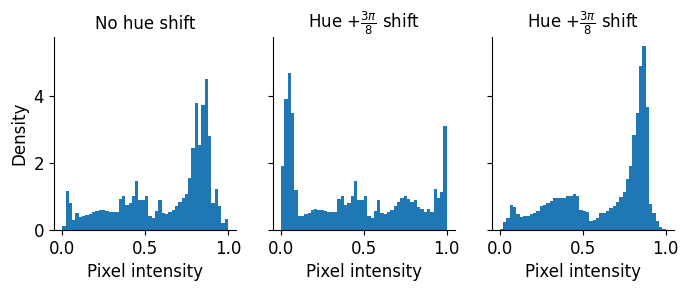

In [8]:
from tqdm import tqdm

fig, ax = plt.subplots(1, 3, figsize=(8, 2.5), sharey=True)
font_size = 12

# Default dataset (hue shift = 0)
all_pixels_test = []

for img, _ in tqdm(hue_path[0.0]):

    img = np.array(img)

    # PathMNIST is usually HWC (H, W, C)
    first_channel = img[..., 0]   # ONLY channel 0

    all_pixels_test.append(first_channel.reshape(-1))

all_pixels_test = np.concatenate(all_pixels_test)
print(f'Mean: {all_pixels_test.mean():.4f}, median: {np.median(all_pixels_test):.4f}')


ax[0].hist(all_pixels_test, bins=50, range=(0, 1), density=True)
ax[0].set_xlabel("Pixel intensity", fontsize=font_size)
ax[0].set_ylabel("Density", fontsize=font_size)
ax[0].set_title("No hue shift", fontsize=font_size)


# Hue shifted dataset (hue shift = 0.25)
all_pixels_test_shifted = []

for img, _ in tqdm(hue_path[0.1875]):

    img = np.array(img)

    # PathMNIST is usually HWC (H, W, C)
    first_channel = img[..., 0]   # ONLY channel 0

    all_pixels_test_shifted.append(first_channel.reshape(-1))

all_pixels_test_shifted = np.concatenate(all_pixels_test_shifted)
print('Hue shift')
print(f'Mean: {all_pixels_test_shifted.mean():.4f}, median: {np.median(all_pixels_test_shifted):.4f}')
ax[1].hist(all_pixels_test_shifted, bins=50, range=(0, 1), density=True)
ax[1].set_xlabel("Pixel intensity", fontsize=font_size)
ax[1].set_title(r"Hue $+\frac{3\pi}{8}$ shift", fontsize=font_size)

# Train data
all_pixels_train = []

for img, _ in tqdm(pmnist_train):

    img = np.array(img)

    # PathMNIST is usually HWC (H, W, C)
    first_channel = img[..., 0]   # ONLY channel 0

    all_pixels_train.append(first_channel.reshape(-1))

all_pixels_train = np.concatenate(all_pixels_train)
print('Hue shift')
print(f'Mean: {all_pixels_train.mean():.4f}, median: {np.median(all_pixels_train):.4f}')
ax[2].hist(all_pixels_train, bins=50, range=(0, 1), density=True)
ax[2].set_xlabel("Pixel intensity", fontsize=font_size)
ax[2].set_title(r"Hue $+\frac{3\pi}{8}$ shift", fontsize=font_size)



for a in ax:
    a.spines['top'].set_visible(False)
    a.spines['right'].set_visible(False)
    a.tick_params(axis='both', labelsize=font_size)

# fig.savefig('figures/hue_shift_pixel_distribution.pdf', bbox_inches='tight')


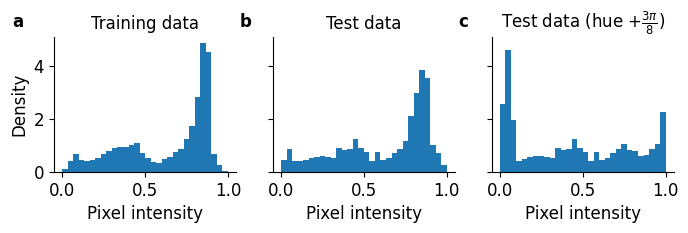

In [19]:
from tqdm import tqdm

fig, ax = plt.subplots(1, 3, figsize=(8, 1.75), sharey=True)
font_size = 12

# Train data
ax[0].hist(all_pixels_train, bins=30, range=(0, 1), density=True)
ax[0].set_xlabel("Pixel intensity", fontsize=font_size)
ax[0].set_title(r"Training data", fontsize=font_size)
ax[0].set_ylabel("Density", fontsize=font_size)

# Default dataset (hue shift = 0)
ax[1].hist(all_pixels_test, bins=30, range=(0, 1), density=True)
ax[1].set_xlabel("Pixel intensity", fontsize=font_size)
ax[1].set_title("Test data", fontsize=font_size)

# Hue shifted dataset (hue shift = 0.25)
ax[2].hist(all_pixels_test_shifted, bins=30, range=(0, 1), density=True)
ax[2].set_xlabel("Pixel intensity", fontsize=font_size)
ax[2].set_title(r"Test data (hue $+\frac{3\pi}{8}$)", fontsize=font_size)

for a in ax:
    a.spines['top'].set_visible(False)
    a.spines['right'].set_visible(False)
    a.tick_params(axis='both', labelsize=font_size)

# abc labels
ax[0].text(-0.23, 1.08, 'a', transform=ax[0].transAxes, fontsize=font_size, fontweight='bold')
ax[1].text(-0.18, 1.08, 'b', transform=ax[1].transAxes, fontsize=font_size, fontweight='bold')
ax[2].text(-0.18, 1.08, 'c', transform=ax[2].transAxes, fontsize=font_size, fontweight='bold')

fig.savefig('figures/hue_shift_pixel_distribution.pdf', bbox_inches='tight')
